## 카테고리 국내/외국 구분 + 대/중/소분류 분리

`aladin_category_name` 컬럼의 `>` 구분자를 기준으로 4개 컬럼으로 나눕니다.

- `category_origin` : 국내도서 / 외국도서 등 최상위 구분
- `category_large`  : 대분류
- `category_medium` : 중분류 (없으면 NaN)
- `category_small`  : 소분류 (없으면 NaN)

In [ ]:
import pandas as pd
import re

df = pd.read_csv('../../data/processed/books_with_category.csv')
print(df.shape)
df.head(3)

(47787, 12)


,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s,aladin_category_id,aladin_category_name
0,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한...,"['여행', '건강/취미']",https://image.aladin.co.kr/product/3917/39/cov...,53529.0,국내도서>건강/취미>등산/캠핑
1,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조...",['소설'],https://image.aladin.co.kr/product/24410/85/co...,51126.0,국내도서>소설/시/희곡>로맨스소설>외국 로맨스소설
2,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",이희준 저,이야기나무,2015-07-07,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",전국에 흩어진 전통시장을 20대 청춘의 시선으로 기록하다! 공모전 준비와 스펙 쌓기...,['여행'],https://image.aladin.co.kr/product/6266/95/cov...,50846.0,국내도서>여행>국내 여행가이드>전국여행 가이드북


In [ ]:
# aladin_category_name 을 '>' 기준으로 분리해 4개 컬럼 추가
category_split = df['aladin_category_name'].str.split('>', expand=True)

df['category_origin'] = category_split[0].str.strip()                                              # 국내도서 / 외국도서
df['category_large']  = category_split[1].str.strip() if 1 in category_split.columns else None     # 대분류
df['category_medium'] = category_split[2].str.strip() if 2 in category_split.columns else None     # 중분류
df['category_small']  = category_split[3].str.strip() if 3 in category_split.columns else None     # 소분류

print(df[['aladin_category_name', 'category_origin', 'category_large', 'category_medium', 'category_small']].head(10))

                           aladin_category_name category_origin  \
0                              국내도서>건강/취미>등산/캠핑            국내도서   
1                   국내도서>소설/시/희곡>로맨스소설>외국 로맨스소설            국내도서   
2                    국내도서>여행>국내 여행가이드>전국여행 가이드북            국내도서   
3                       국내도서>초등학교참고서>영재교육원대비>수학            국내도서   
4                      국내도서>어린이>동화/명작/고전>외국창작동화            국내도서   
5                 국내도서>수험서/자격증>산업인력관리공단>기계분야>금형            국내도서   
6  국내도서>컴퓨터/모바일>프로그래밍 개발/방법론>애플/아이폰/안드로이드 프로그래밍            국내도서   
7                       국내도서>에세이>명사에세이>기타 명사에세이            국내도서   
8                          국내도서>자기계발>힐링>마음 다스리기            국내도서   
9                      국내도서>수험서/자격증>공무원 수험서>기술직            국내도서   

  category_large category_medium      category_small  
0          건강/취미           등산/캠핑                 NaN  
1        소설/시/희곡           로맨스소설            외국 로맨스소설  
2             여행        국내 여행가이드           전국여행 가이드북  
3        초등학교참고서         영재교육원대비          

In [ ]:
# 분포 확인
print('국내/외국 구분:', df['category_origin'].value_counts().to_dict())
print()
print('대분류 종류:', df['category_large'].nunique())
print(df['category_large'].value_counts().head(10))
print()
print('중분류 결측:', df['category_medium'].isna().sum())
print('소분류 결측:', df['category_small'].isna().sum())

국내/외국 구분: {'국내도서': 47733, '외국도서': 1, '전자책': 1}

대분류 종류: 29
category_large
수험서/자격증      4985
소설/시/희곡      4965
어린이          4950
유아           3117
종교/역학        2424
인문학          2358
에세이          2328
경제경영         2321
대학교재/전문서적    2206
사회과학         2018
Name: count, dtype: int64

중분류 결측: 54
소분류 결측: 7822


In [ ]:
# 각 레벨별 빈도 Top N
TOP_N = 10

for col, label in [
    ('category_origin', '국내/외국 구분'),
    ('category_large',  '대분류'),
    ('category_medium', '중분류'),
    ('category_small',  '소분류'),
]:
    top = df[col].value_counts().head(TOP_N)
    print(f'▶ {label} Top {TOP_N}')
    print(top.to_string())
    print()

▶ 국내/외국 구분 Top 10
category_origin
국내도서    47733
외국도서        1
전자책         1

▶ 대분류 Top 10
category_large
수험서/자격증      4985
소설/시/희곡      4965
어린이          4950
유아           3117
종교/역학        2424
인문학          2358
에세이          2328
경제경영         2321
대학교재/전문서적    2206
사회과학         2018

▶ 중분류 Top 10
category_medium
공무원 수험서      1842
기독교(개신교)     1766
동화/명작/고전     1595
그림책          1522
한국에세이        1452
시            1065
한국소설          940
놀이책           859
과학/수학/컴퓨터     785
성공            748

▶ 소분류 Top 10
category_small
나라별 그림책           1291
7/9급 공무원          1221
한국시                959
2000년대 이후 한국소설     813
국내창작동화             740
성공학                664
기독교(개신교) 신앙생활      602
외국창작동화             500
그림책                462
기독교(개신교) 목회/신학     453



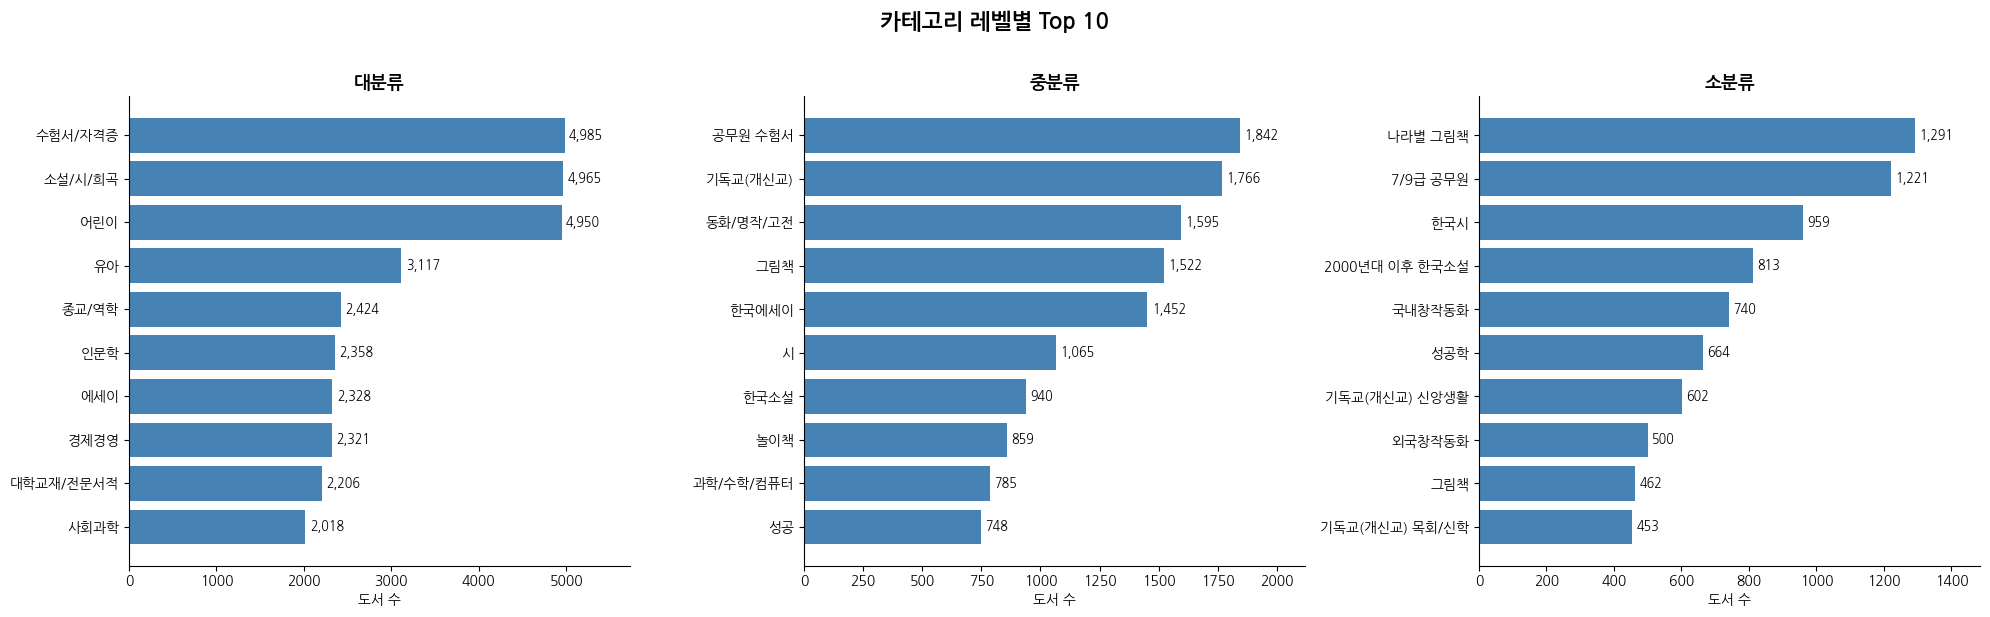

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

TOP_N = 10
levels = [
    ('category_large',  '대분류'),
    ('category_medium', '중분류'),
    ('category_small',  '소분류'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'카테고리 레벨별 Top {TOP_N}', fontsize=16, fontweight='bold', y=1.02)

for ax, (col, label) in zip(axes, levels):
    top = df[col].value_counts().head(TOP_N)
    bars = ax.barh(top.index[::-1], top.values[::-1], color='steelblue')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('도서 수')
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width() + max(top.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)
    ax.set_xlim(0, max(top.values) * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 연도별 출판 권수
df['publish_year'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.year
year_counts = df['publish_year'].value_counts().sort_index()

print(f"{'연도':>6}  {'권수':>6}")
print('-' * 16)
for year, count in year_counts.items():
    print(f"{int(year):>6}  {count:>6,}")
print('-' * 16)
print(f"{'합계':>6}  {year_counts.sum():>6,}")

    연도      권수
----------------
     1       1
  1974       1
  1988       1
  1990       2
  1991       2
  1992       4
  1993       3
  1994      13
  1995      18
  1996      15
  1997      31
  1998      27
  1999      87
  2000     239
  2001     283
  2002     238
  2003     263
  2004     278
  2005     374
  2006     611
  2007     908
  2008   1,516
  2009   1,769
  2010   1,850
  2011   1,833
  2012   1,943
  2013   2,198
  2014   2,366
  2015   2,626
  2016   2,517
  2017   2,352
  2018   2,464
  2019   2,893
  2020   3,075
  2021   3,323
  2022   3,201
  2023   3,119
  2024   3,356
  2025   1,983
  2026       4
----------------
    합계  47,787


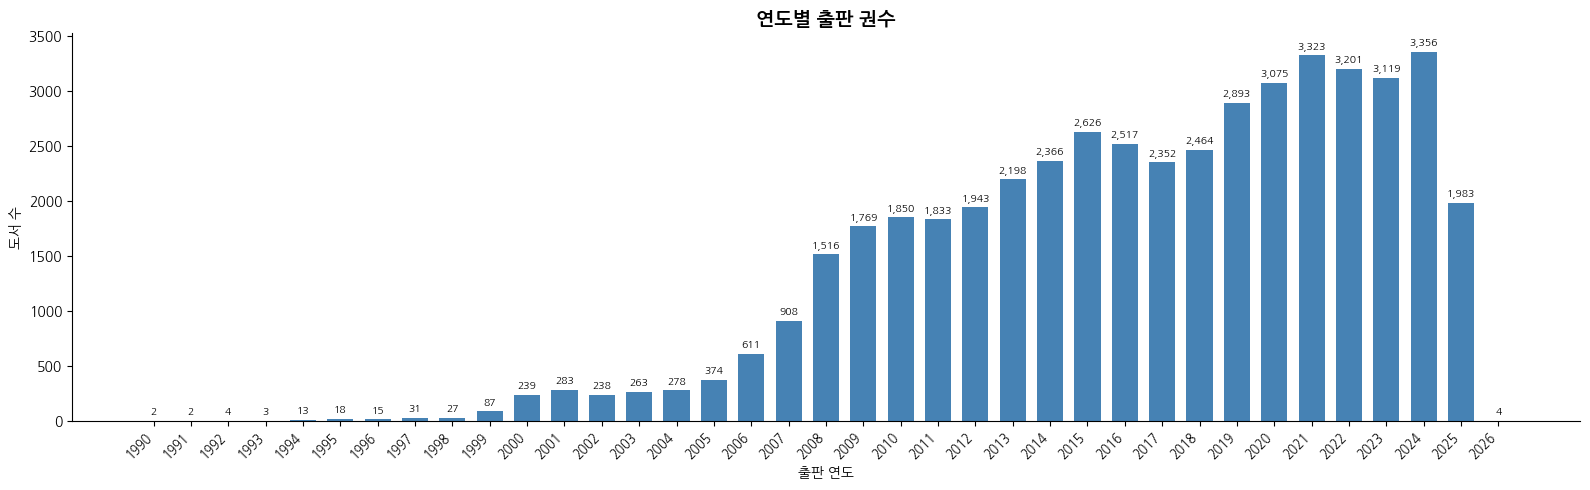

In [ ]:
# 연도별 출판 권수 시각화 (권수 1인 연도 제외)
df['publish_year'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.year
year_counts = df['publish_year'].value_counts().sort_index()
year_counts = year_counts[year_counts > 1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(year_counts.index, year_counts.values, color='steelblue', width=0.7)
ax.set_title('연도별 출판 권수', fontsize=14, fontweight='bold')
ax.set_xlabel('출판 연도')
ax.set_ylabel('도서 수')
ax.set_xticks(year_counts.index)
ax.set_xticklabels(year_counts.index.astype(int), rotation=45, ha='right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y + max(year_counts.values) * 0.01, f'{y:,}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

### author 컬럼 분리
- 한 컬럼 안에 [저, 역, 감수, 공저]가 같이 존재함
- 컬럼 나누기 [”author”, “translator”, “supervisor”]

In [ ]:
df['ori_author'] = df['author']

In [ ]:
def parse_author(text):
    if not isinstance(text, str):
        return [], [], []
    
    author, translator, supervisor = [], [], []
    
    # '외 N명' 제거
    text = re.sub(r'\s*외\s*\d+명', '', text)
    
    # 복합 태그 임시 치환
    text = re.sub(r'글,\s*그림', '글그림', text)
    text = re.sub(r'글,\s*기획', '글기획', text)
    text = re.sub(r'글,\s*만화', '글만화', text)
    text = re.sub(r'기획,\s*제작', '기획제작', text)
    
    role_pattern = r'(공저|편저|편역|공역|저|역|감수|자문|글그림|글기획|글만화|기획제작|글|그림|만화|기획|제작|편)$'
    
    # '/' 기준으로 역할별 세그먼트 분리
    segments = text.split('/')
    
    for seg in segments:
        seg = seg.strip()
        
        # ',' 기준으로 분리
        parts = [p.strip() for p in seg.split(',') if p.strip()]
        
        last_name = None  # 이전 이름 저장 (태그 단독 케이스 대비)
        
        # 각 part에서 역할 태그 추출 후 이름 파싱
        for part in parts:
            tag_match = re.search(role_pattern, part)
            
            if tag_match:
                tag = tag_match.group()
                name = part[:tag_match.start()].strip()
                
                # 이름 없는 태그 단독 케이스 → 이전 이름 재사용
                if not name:
                    name = last_name
                
                if not name:
                    continue
                
                last_name = name  # 이름 업데이트
                
                if tag in ('역', '공역', '편역'):
                    translator.append(name)
                elif tag in ('감수', '자문'):
                    supervisor.append(name)
                else:  # 저, 공저, 편저, 글그림, 글기획, 글만화, 기획제작, 글, 그림, 만화, 기획, 제작
                    author.append(name)
            else:
                # 태그 없는 경우 → author
                author.append(part)
                last_name = part
    
    return author, translator, supervisor

In [ ]:
# author 컬럼을 파싱하여 세 컬럼으로 분리
df[['author', 'translator', 'supervisor']] = df['author'].apply(
    lambda x: pd.Series(parse_author(x))
)

df.head(5)

,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s,aladin_category_id,aladin_category_name,category_origin,category_large,category_medium,category_small,publish_year,ori_author,translator,supervisor
0,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한...,"['여행', '건강/취미']",https://image.aladin.co.kr/product/3917/39/cov...,53529.0,국내도서>건강/취미>등산/캠핑,국내도서,건강/취미,등산/캠핑,NaN,2014,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[]
1,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조...",['소설'],https://image.aladin.co.kr/product/24410/85/co...,51126.0,국내도서>소설/시/희곡>로맨스소설>외국 로맨스소설,국내도서,소설/시/희곡,로맨스소설,외국 로맨스소설,2020,천하귀원 저/김지혜 역,[김지혜],[]
2,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",[이희준],이야기나무,2015-07-07,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",전국에 흩어진 전통시장을 20대 청춘의 시선으로 기록하다! 공모전 준비와 스펙 쌓기...,['여행'],https://image.aladin.co.kr/product/6266/95/cov...,50846.0,국내도서>여행>국내 여행가이드>전국여행 가이드북,국내도서,여행,국내 여행가이드,전국여행 가이드북,2015,이희준 저,[],[]
3,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,[중국사천대학],씨실과날실,2019-01-30,204,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,시중에 나와있는 영재교육 교재와 차별화된 학습과정을 통하여 또래 아이들보다 뛰어난 ...,['초등학교 참고서'],https://image.aladin.co.kr/product/18015/36/co...,52199.0,국내도서>초등학교참고서>영재교육원대비>수학,국내도서,초등학교참고서,영재교육원대비,수학,2019,중국사천대학 저 / 이수진 역 / 멘사수학연구소 감수,[이수진],[멘사수학연구소]
4,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,[편집부],춘희네책방,2025-02-18,0,초등학교 1 2학년 교과과정 연계 도서 세트입니다.,1. 블랙팬서 자신감 우정 성장 국어 2-1 8. 다양한 작품을 감상해요 국어 2-...,['어린이'],https://image.aladin.co.kr/product/35898/84/co...,48877.0,국내도서>어린이>동화/명작/고전>외국창작동화,국내도서,어린이,동화/명작/고전,외국창작동화,2025,편집부 저,[],[]


In [ ]:
df[df['translator'].apply(lambda x: isinstance(x, list) and len(x) > 0)][['author', 'translator', 'supervisor']]

,author,translator,supervisor
1,[천하귀원],[김지혜],[]
3,[중국사천대학],[이수진],[멘사수학연구소]
21,[자오촨둥],[노만수],[]
23,[소메이 다메히토],[정혜원],[]
31,[김세현],[박수밀],[]
...,...,...,...
47773,[코넬리아 푼케],[배수아],[]
47775,[제임스 앨런 맥퍼슨],[안정효],[]
47777,"[숀 오마라, 케리 쿠퍼]",[엄창호],[]
47778,[서유구],[임원경제연구소],[]


### publish_date : timezone 표시

In [ ]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['publish_year'] = df['publish_date_dt'].dt.year

In [ ]:
df['publish_year'].value_counts().sort_index()

publish_year
1          1
1974       1
1988       1
1990       2
1991       2
1992       4
1993       3
1994      13
1995      18
1996      15
1997      31
1998      27
1999      87
2000     239
2001     283
2002     238
2003     263
2004     278
2005     374
2006     611
2007     908
2008    1516
2009    1769
2010    1850
2011    1833
2012    1943
2013    2198
2014    2366
2015    2626
2016    2517
2017    2352
2018    2464
2019    2893
2020    3075
2021    3323
2022    3201
2023    3119
2024    3356
2025    1983
2026       4
Name: count, dtype: int64

In [ ]:
df = df[df['publish_year'] >= 1974]

In [ ]:
df['publish_year'].value_counts().sort_index()

publish_year
1974       1
1988       1
1990       2
1991       2
1992       4
1993       3
1994      13
1995      18
1996      15
1997      31
1998      27
1999      87
2000     239
2001     283
2002     238
2003     263
2004     278
2005     374
2006     611
2007     908
2008    1516
2009    1769
2010    1850
2011    1833
2012    1943
2013    2198
2014    2366
2015    2626
2016    2517
2017    2352
2018    2464
2019    2893
2020    3075
2021    3323
2022    3201
2023    3119
2024    3356
2025    1983
2026       4
Name: count, dtype: int64

In [ ]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.tz_localize('Asia/Seoul', nonexistent='NaT', ambiguous='NaT')
df['publish_year'] = df['publish_date_dt'].dt.year
df['publish_date_dt'] = df['publish_date_dt'].dt.strftime('%Y-%m-%dT%H:%M:%S+09:00')

### book_intro + pub_review

In [ ]:
# 두 필드 합치기
df['intro_review'] = df['book_intro'].fillna('') + ' ' + df['pub_review'].fillna('')

# 합친 길이 분포 확인 (threshold 결정용)
df['intro_review_len'] = df['intro_review'].str.len()
print(df['intro_review_len'].describe(percentiles=[.25, .5, .75, .95, .99]))

count    47786.000000
mean      1923.553342
std       1474.224482
min         60.000000
25%        930.000000
50%       1567.000000
75%       2487.000000
95%       4581.000000
99%       7059.900000
max      44364.000000
Name: intro_review_len, dtype: float64


In [ ]:
# 데이터 길이 기준이 아니라 토큰 길이 기준으로 truncate 진행

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

df['token_len'] = df['intro_review'].apply(lambda x: len(tokenizer.encode(x)))
print(df['token_len'].describe(percentiles=[.75, .95, .99]))

# 초과하는 비율 확인
print(f"8192 초과 비율: {(df['token_len'] > 8192).mean():.2%}")

/home/jjeong3150/anaconda3/envs/book-curation/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8387 > 8192). Running this sequence through the model will result in indexing errors


count    47786.000000
mean      1029.881932
std        801.579390
min         35.000000
75%       1332.000000
95%       2480.000000
99%       3865.150000
max      23726.000000
Name: token_len, dtype: float64
8192 초과 비율: 0.04%


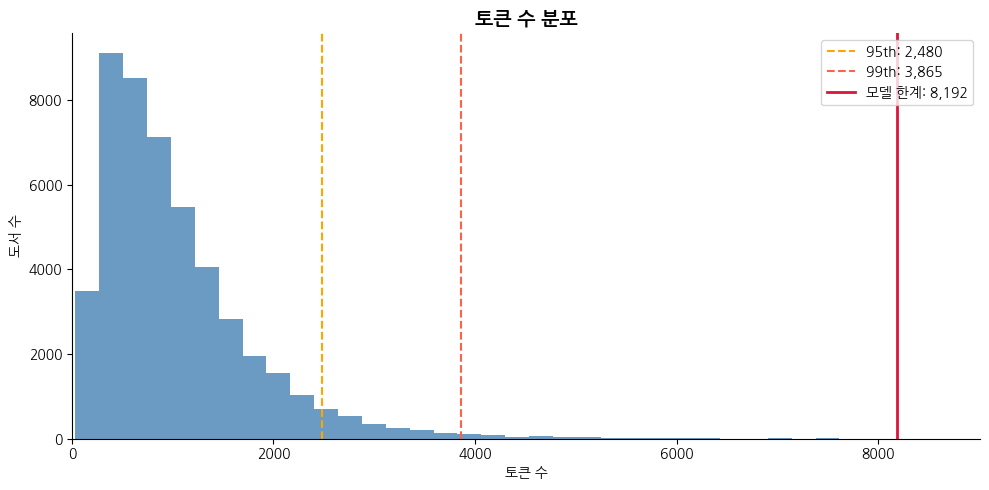

In [ ]:
# 토큰 수 분포 시각화
p95 = df['token_len'].quantile(0.95)
p99 = df['token_len'].quantile(0.99)
model_limit = 8192

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['token_len'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(p95,         color='orange', linestyle='--', linewidth=1.5, label=f'95th: {p95:,.0f}')
ax.axvline(p99,         color='tomato',  linestyle='--', linewidth=1.5, label=f'99th: {p99:,.0f}')
ax.axvline(model_limit, color='crimson', linestyle='-',  linewidth=2,   label=f'모델 한계: {model_limit:,}')
ax.set_xlim(0, model_limit * 1.1)
ax.set_title('토큰 수 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('토큰 수')
ax.set_ylabel('도서 수')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 토큰 길이 상위 1% (99th percentile 초과) 제거
p99 = df['token_len'].quantile(0.99)
before = len(df)
df = df[df['token_len'] <= p99].reset_index(drop=True)
after = len(df)
print(f'기준: {p99:.0f} tokens')
print(f'제거: {before - after:,}건 ({(before - after) / before * 100:.2f}%)')
print(f'남은 데이터: {after:,}건')

기준: 3865 tokens
제거: 478건 (1.00%)
남은 데이터: 47,308건


In [ ]:
df.columns

Index(['isbn', 'title', 'author', 'publisher', 'publish_date', 'page',
       'book_intro', 'pub_review', 'cate_depth1', 'ori_cover_s',
       'aladin_category_id', 'aladin_category_name', 'category_origin',
       'category_large', 'category_medium', 'category_small', 'publish_year',
       'ori_author', 'translator', 'supervisor', 'publish_date_dt',
       'intro_review', 'intro_review_len', 'token_len'],
      dtype='str')

In [ ]:
cols = [
    'isbn', 'title', 'author', 'translator',
    'supervisor', 'publisher', 'publish_year',
    'publish_date_dt', 'page', 'book_intro',
    'pub_review', 'intro_review', 'cate_depth1',
    'ori_cover_s', 'aladin_category_name',
    'aladin_category_id', 'category_origin',
    'category_large', 'category_medium', 'category_small'
]
df = df[cols]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')

df.head(5)

레코드 수: 47,308
컬럼 수: 20


,isbn,title,author,translator,supervisor,publisher,publish_year,publish_date_dt,page,book_intro,pub_review,intro_review,cate_depth1,ori_cover_s,aladin_category_name,aladin_category_id,category_origin,category_large,category_medium,category_small
0,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",[],[],화담,2014,2014-03-24T00:00:00+09:00,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한...,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,"['여행', '건강/취미']",https://image.aladin.co.kr/product/3917/39/cov...,국내도서>건강/취미>등산/캠핑,53529.0,국내도서,건강/취미,등산/캠핑,NaN
1,9788963717715,부요황후 1,[천하귀원],[김지혜],[],파란썸 (파란미디어),2020,2020-07-14T00:00:00+09:00,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조...","중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...",['소설'],https://image.aladin.co.kr/product/24410/85/co...,국내도서>소설/시/희곡>로맨스소설>외국 로맨스소설,51126.0,국내도서,소설/시/희곡,로맨스소설,외국 로맨스소설
2,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",[이희준],[],[],이야기나무,2015,2015-07-07T00:00:00+09:00,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",전국에 흩어진 전통시장을 20대 청춘의 시선으로 기록하다! 공모전 준비와 스펙 쌓기...,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",['여행'],https://image.aladin.co.kr/product/6266/95/cov...,국내도서>여행>국내 여행가이드>전국여행 가이드북,50846.0,국내도서,여행,국내 여행가이드,전국여행 가이드북
3,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,[중국사천대학],[이수진],[멘사수학연구소],씨실과날실,2019,2019-01-30T00:00:00+09:00,204,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,시중에 나와있는 영재교육 교재와 차별화된 학습과정을 통하여 또래 아이들보다 뛰어난 ...,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...,['초등학교 참고서'],https://image.aladin.co.kr/product/18015/36/co...,국내도서>초등학교참고서>영재교육원대비>수학,52199.0,국내도서,초등학교참고서,영재교육원대비,수학
4,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,[편집부],[],[],춘희네책방,2025,2025-02-18T00:00:00+09:00,0,초등학교 1 2학년 교과과정 연계 도서 세트입니다.,1. 블랙팬서 자신감 우정 성장 국어 2-1 8. 다양한 작품을 감상해요 국어 2-...,초등학교 1 2학년 교과과정 연계 도서 세트입니다. 1. 블랙팬서 자신감 우정 성장...,['어린이'],https://image.aladin.co.kr/product/35898/84/co...,국내도서>어린이>동화/명작/고전>외국창작동화,48877.0,국내도서,어린이,동화/명작/고전,외국창작동화


In [ ]:
# 저장
output_path = '../../data/processed/books_split.csv'
df.to_csv(output_path, index=False)
print(f'저장 완료: {output_path}')
print(df.shape)

저장 완료: ../../data/processed/books_split.csv
(47308, 20)


## 데이터 적재

In [ ]:
import sys
import os
import io
import uuid
import math
import contextlib
from tqdm import tqdm
from qdrant_client.models import PointStruct

sys.path.insert(0, os.path.abspath('../..'))

from src.db.qdrant import QdrantDB
from src.embedding.embedder import LocalEmbedder


In [ ]:
embedder = LocalEmbedder()
db = QdrantDB(vector_size=1024, timeout=1200)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10470.96it/s]


In [ ]:
# 컬렉션 리스트 확인

collections = db.get_collections().collections
c_list = []

for c in collections:
    c_list.append(c)
    info = db.client.get_collection(c.name)
    print(f"{c.name} — 벡터 수: {info.points_count:,}, 벡터 차원:{info.config.params.vectors.size}")

if len(c_list) == 0:
    print("저장된 collection이 없습니다.")

저장된 collection이 없습니다.


In [ ]:
# # 기존 컬렉션 삭제
# db.delete_collection("books_v2")

In [ ]:
BATCH_SIZE = 64

def to_payload_val(v):
    if isinstance(v, float) and math.isnan(v):
        return None
    return v

def to_int_val(v):
    if isinstance(v, float) and math.isnan(v):
        return None
    return int(v)

INDEXES = [
    ('cate_depth1',     'keyword'),
    ('publish_year',    'integer'),
    ('author',          'text'),
    ('title',           'text'),
    ('category_origin', 'keyword'),
    ('category_large',  'keyword'),
    ('category_medium', 'keyword'),
    ('category_small',  'keyword'),
]


In [ ]:
# # ── 1. books_intro_48k ───────────────────────────────────────────────
# COLLECTION = 'books_intro_48k'

# existing = [c.name for c in db.get_collections().collections]
# if COLLECTION not in existing:
#     db.create_collection(COLLECTION)
#     for field, schema in INDEXES:
#         db.create_payload_index(COLLECTION, field, schema)
# else:
#     print(f'컬렉션 이미 존재: {COLLECTION}')

# records = df.to_dict('records')

# for i in tqdm(range(0, len(records), BATCH_SIZE), desc=f'{COLLECTION} 적재'):
#     batch = records[i:i + BATCH_SIZE]
#     vectors = embedder.embed_batch([r['book_intro'] if isinstance(r['book_intro'], str) else '' for r in batch])

#     points = [
#         PointStruct(
#             id=str(uuid.uuid5(uuid.NAMESPACE_DNS, str(row['isbn']))),
#             vector=vectors[j],
#             payload={
#                 'isbn':              row['isbn'],
#                 'title':             to_payload_val(row['title']),
#                 'author':            row['author'],
#                 'translator':        row['translator'],
#                 'supervisor':        row['supervisor'],
#                 'publisher':         to_payload_val(row['publisher']),
#                 'publish_year':      to_int_val(row['publish_year']),
#                 'publish_date':      to_payload_val(row['publish_date_dt']),
#                 'page':              to_int_val(row['page']),
#                 'book_intro':        to_payload_val(row['book_intro']),
#                 'cate_depth1':       to_payload_val(row['cate_depth1']),
#                 'cover_url':         to_payload_val(row['ori_cover_s']),
#                 'aladin_category_id':   to_payload_val(row['aladin_category_id']),
#                 'aladin_category_name': to_payload_val(row['aladin_category_name']),
#                 'category_origin':   to_payload_val(row['category_origin']),
#                 'category_large':    to_payload_val(row['category_large']),
#                 'category_medium':   to_payload_val(row['category_medium']),
#                 'category_small':    to_payload_val(row['category_small']),
#             }
#         )
#         for j, row in enumerate(batch)
#     ]

#     with contextlib.redirect_stdout(io.StringIO()):
#         db.upsert(COLLECTION, points)

# print(f'\n총 {len(records):,}건 적재 완료 → {COLLECTION}')


✅ 컬렉션 생성 완료: books_intro_48k
✅ 인덱스 생성 완료: cate_depth1 (keyword)
✅ 인덱스 생성 완료: publish_year (integer)
✅ 인덱스 생성 완료: author (text)
✅ 인덱스 생성 완료: title (text)
✅ 인덱스 생성 완료: category_origin (keyword)
✅ 인덱스 생성 완료: category_large (keyword)
✅ 인덱스 생성 완료: category_medium (keyword)
✅ 인덱스 생성 완료: category_small (keyword)


books_intro_48k 적재: 100%|██████████| 740/740 [1:55:19<00:00,  9.35s/it]  


총 47,308건 적재 완료 → books_intro_48k


In [ ]:
# ── 2. books_merged_48k ──────────────────────────────────────────────
COLLECTION = 'books_merged_48k'

existing = [c.name for c in db.get_collections().collections]
if COLLECTION not in existing:
    db.create_collection(COLLECTION)
    for field, schema in INDEXES:
        db.create_payload_index(COLLECTION, field, schema)
else:
    print(f'컬렉션 이미 존재: {COLLECTION}')

records = df.to_dict('records')

for i in tqdm(range(0, len(records), BATCH_SIZE), desc=f'{COLLECTION} 적재'):
    batch = records[i:i + BATCH_SIZE]
    vectors = embedder.embed_batch([r['intro_review'] for r in batch])

    points = [
        PointStruct(
            id=str(uuid.uuid5(uuid.NAMESPACE_DNS, str(row['isbn']))),
            vector=vectors[j],
            payload={
                'isbn':              row['isbn'],
                'title':             to_payload_val(row['title']),
                'author':            row['author'],
                'translator':        row['translator'],
                'supervisor':        row['supervisor'],
                'publisher':         to_payload_val(row['publisher']),
                'publish_year':      to_int_val(row['publish_year']),
                'publish_date':      to_payload_val(row['publish_date_dt']),
                'page':              to_int_val(row['page']),
                'book_intro':        to_payload_val(row['book_intro']),
                'pub_review':        to_payload_val(row['pub_review']),
                'cate_depth1':       to_payload_val(row['cate_depth1']),
                'cover_url':         to_payload_val(row['ori_cover_s']),
                'aladin_category_id':   to_payload_val(row['aladin_category_id']),
                'aladin_category_name': to_payload_val(row['aladin_category_name']),
                'category_origin':   to_payload_val(row['category_origin']),
                'category_large':    to_payload_val(row['category_large']),
                'category_medium':   to_payload_val(row['category_medium']),
                'category_small':    to_payload_val(row['category_small']),
            }
        )
        for j, row in enumerate(batch)
    ]

    with contextlib.redirect_stdout(io.StringIO()):
        db.upsert(COLLECTION, points)

print(f'\n총 {len(records):,}건 적재 완료 → {COLLECTION}')


✅ 컬렉션 생성 완료: books_merged_48k
✅ 인덱스 생성 완료: cate_depth1 (keyword)
✅ 인덱스 생성 완료: publish_year (integer)
✅ 인덱스 생성 완료: author (text)
✅ 인덱스 생성 완료: title (text)
✅ 인덱스 생성 완료: category_origin (keyword)
✅ 인덱스 생성 완료: category_large (keyword)
✅ 인덱스 생성 완료: category_medium (keyword)
✅ 인덱스 생성 완료: category_small (keyword)


books_merged_48k 적재:  43%|████▎     | 320/740 [22:48:33<38:05:02, 326.43s/it] 